In [1]:
# Install required libraries.
# pandas and numpy are used for data handling.
# matplotlib and seaborn are used for plots.
# scikit-learn provides the 20 Newsgroups dataset.
# nltk is used for sentence counting.
# wordcloud is used to create the word cloud.

!pip -q install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

In [2]:
# Import all required libraries.

import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

import nltk

# punkt and punkt_tab are needed by NLTK for sentence tokenisation.
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

# Set a clean visual style for plots.
sns.set_theme(style="whitegrid")

# Make dataframe text columns easier to read.
pd.set_option("display.max_colwidth", 120)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
# Load the 20 Newsgroups dataset.
#
# We use subset="all" so that both train and test documents are included.
#
# We remove headers, footers, and quoted replies because these often contain
# email metadata or repeated text from previous messages.
#
# This gives a cleaner version of the document content for EDA.

ng = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

df_20ng = pd.DataFrame({
    "dataset": "20 Newsgroups",
    "text": ng.data,
    "label_id": ng.target,
    "label": [ng.target_names[i] for i in ng.target]
})

df_20ng.head()

,dataset,text,label_id,label
0,20 Newsgroups,\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pe...,10,rec.sport.hockey
1,20 Newsgroups,My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM. Does an...,3,comp.sys.ibm.pc.hardware
2,20 Newsgroups,"\n\n\n\n\tFinally you said what you dream about. Mediterranean???? That was new....\n\tThe area will be ""greater"" af...",17,talk.politics.mideast
3,20 Newsgroups,\nThink!\n\nIt's the SCSI card doing the DMA transfers NOT the disks...\n\nThe SCSI card can do DMA transfers contai...,3,comp.sys.ibm.pc.hardware
4,20 Newsgroups,1) I have an old Jasmine drive which I cannot use with my new system.\n My understanding is that I have to upsate...,4,comp.sys.mac.hardware


In [4]:
# Check the basic shape of the dataset.

print("Number of documents:", len(df_20ng))
print("Number of classes:", df_20ng["label"].nunique())
print("Class names:")
print(df_20ng["label"].unique())

Number of documents: 18846
Number of classes: 20
Class names:
['rec.sport.hockey' 'comp.sys.ibm.pc.hardware' 'talk.politics.mideast'
 'comp.sys.mac.hardware' 'sci.electronics' 'talk.religion.misc'
 'sci.crypt' 'sci.med' 'alt.atheism' 'rec.motorcycles' 'rec.autos'
 'comp.windows.x' 'comp.graphics' 'sci.space' 'talk.politics.guns'
 'misc.forsale' 'rec.sport.baseball' 'talk.politics.misc'
 'comp.os.ms-windows.misc' 'soc.religion.christian']


In [5]:
# This function counts sentences in a document.
#
# It first tries to use NLTK's sentence tokenizer.
# If there is an issue with the tokenizer, it falls back to a simple rule-based
# split using punctuation marks.

def safe_sentence_count(text):
    text = "" if pd.isna(text) else str(text)

    if not text.strip():
        return 0

    try:
        return len(sent_tokenize(text))
    except LookupError:
        return len([s for s in re.split(r"[.!?]+", text) if s.strip()])

In [6]:
# This function creates the main document-level EDA statistics.
#
# For each document, it calculates:
# - character count
# - word count
# - sentence count
# - average words per sentence
# - URL count
# - email count
# - alphabetic character ratio
#
# It also creates two useful flags:
# - too_short_sentence_model
# - too_noisy_sentence_model
#
# These are simple heuristic rules to estimate whether a document is suitable
# for sentence-level modelling.

def basic_text_stats(df, text_col="text"):
    out = df.copy()

    # Ensure all documents are strings.
    out[text_col] = out[text_col].fillna("").astype(str)

    # Count characters.
    out["char_count"] = out[text_col].str.len()

    # Count words using a simple regular expression.
    out["word_count"] = out[text_col].apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    # Count sentences.
    out["sentence_count"] = out[text_col].apply(safe_sentence_count)

    # Calculate average words per sentence.
    # Replace 0 with NaN to avoid division by zero.
    out["avg_words_per_sentence"] = (
        out["word_count"] / out["sentence_count"].replace(0, np.nan)
    )

    # Count URLs.
    out["url_count"] = out[text_col].str.count(r"https?://|www\.")

    # Count email-like strings.
    out["email_count"] = out[text_col].str.count(
        r"\b[\w\.-]+@[\w\.-]+\.\w+\b"
    )

    # Calculate the proportion of alphabetic characters.
    # Very low values may indicate noisy text, code, metadata, or symbols.
    out["alpha_ratio"] = out[text_col].apply(
        lambda x: sum(ch.isalpha() for ch in x) / max(len(x), 1)
    )

    # A document is considered too short if it has fewer than 3 sentences
    # or fewer than 50 words.
    out["too_short_sentence_model"] = (
        (out["sentence_count"] < 2) |
        (out["word_count"] < 20)
    )

    # A document is considered noisy if it has low alphabetic content,
    # many URLs, or no words.
    out["too_noisy_sentence_model"] = (
        (out["url_count"] >= 5) |
        (out["word_count"] == 0)
    )

    # A document is usable if it is neither too short nor too noisy.
    out["usable_sentence_level"] = (
        ~out["too_short_sentence_model"] &
        ~out["too_noisy_sentence_model"]
    )

    out["exceeds_bert_limit"] = out["word_count"] > 350

    return out

In [7]:
# Helper function for plotting distributions such as:
# - sentence count distribution
# - document length distribution

def plot_distribution(df, col, title, bins=60):
    plt.figure(figsize=(8, 4))
    capped = df[col].clip(upper=df[col].quantile(0.99))
    sns.histplot(capped, bins=bins)
    plt.title(title)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Documents")
    plt.show()

In [8]:
# Helper function for plotting class/topic distribution.

def plot_label_distribution(df, label_col="label", top_n=30, title="Class Distribution"):
    counts = df[label_col].value_counts().head(top_n)

    plt.figure(figsize=(9, max(4, top_n * 0.25)))
    sns.barplot(x=counts.values, y=counts.index)

    plt.title(title)
    plt.xlabel("Documents")
    plt.ylabel("Class / Topic")
    plt.show()

In [9]:
# Helper function for vocabulary statistics.
#
# CountVectorizer converts text documents into a document-term matrix.
#
# stop_words="english" removes common English words such as "the", "and", "is".
# min_df=2 ignores terms that appear in only one document.

def vocabulary_stats(texts, max_features=50000, min_df=2, stop_words="english"):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=stop_words,
        min_df=min_df,
        max_features=max_features
    )

    X = vectorizer.fit_transform(texts.fillna(""))

    vocab = vectorizer.get_feature_names_out()
    freqs = np.asarray(X.sum(axis=0)).ravel()

    vocab_df = pd.DataFrame({
        "term": vocab,
        "count": freqs
    }).sort_values("count", ascending=False)

    stats = pd.Series({
        "vocabulary_size": len(vocab),
        "total_counted_tokens": int(freqs.sum()),
        "mean_counted_terms_per_doc": float(X.sum(axis=1).mean()),
        "median_counted_terms_per_doc": float(
            np.median(np.asarray(X.sum(axis=1)).ravel())
        )
    })

    return stats, vocab_df, X

In [10]:
# Helper function to summarise whether documents are suitable for
# sentence-level modelling.

def modelling_quality_summary(df):
    return pd.Series({
        "documents": len(df),
        "too_short_count": int(df["too_short_sentence_model"].sum()),
        "too_short_pct": round(df["too_short_sentence_model"].mean() * 100, 2),
        "too_noisy_count": int(df["too_noisy_sentence_model"].sum()),
        "too_noisy_pct": round(df["too_noisy_sentence_model"].mean() * 100, 2),
        "usable_sentence_level_count": int(df["usable_sentence_level"].sum()),
        "usable_sentence_level_pct": round(df["usable_sentence_level"].mean() * 100, 2),
        "exceeds_bert_limit_pct": round(df["exceeds_bert_limit"].mean() * 100, 2)
    })

In [11]:
# Helper function to print examples of short, medium, and long documents.
#
# The groups are based on word-count quantiles.

def document_examples(df, text_col="text"):
    q1, q2 = df["word_count"].quantile([0.33, 0.66])

    groups = {
        "SHORT DOCUMENTS": df[df["word_count"] <= q1].sort_values("word_count").head(3),
        "MEDIUM DOCUMENTS": df[
            (df["word_count"] > q1) &
            (df["word_count"] <= q2)
        ].sample(3, random_state=42),
        "LONG DOCUMENTS": df[df["word_count"] > q2].sort_values(
            "word_count",
            ascending=False
        ).head(3)
    }

    for name, rows in groups.items():
        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)

        for _, row in rows.iterrows():
            print("\nClass:", row["label"])
            print("Words:", row["word_count"])
            print("Sentences:", row["sentence_count"])

            preview = row[text_col].replace("\n", " ")
            print(textwrap.shorten(preview, width=700))

In [12]:
# Run all calculations for 20 Newsgroups.
#
# This is the main preparation step.
# After this cell, the result cells can display each EDA output one by one.

eda_20ng = basic_text_stats(df_20ng)

vocab_stats_20ng, vocab_20ng, X_20ng = vocabulary_stats(
    eda_20ng["text"]
)

print("20 Newsgroups EDA calculations complete.")
print("Documents:", len(eda_20ng))
print("Classes:", eda_20ng["label"].nunique())

20 Newsgroups EDA calculations complete.
Documents: 18846
Classes: 20


Results

Document Count

In [13]:
pd.DataFrame({
    "dataset": ["20 Newsgroups"],
    "document_count": [len(eda_20ng)],
    "class_count": [eda_20ng["label"].nunique()]
})

,dataset,document_count,class_count
0,20 Newsgroups,18846,20


Sentence Count Distribution

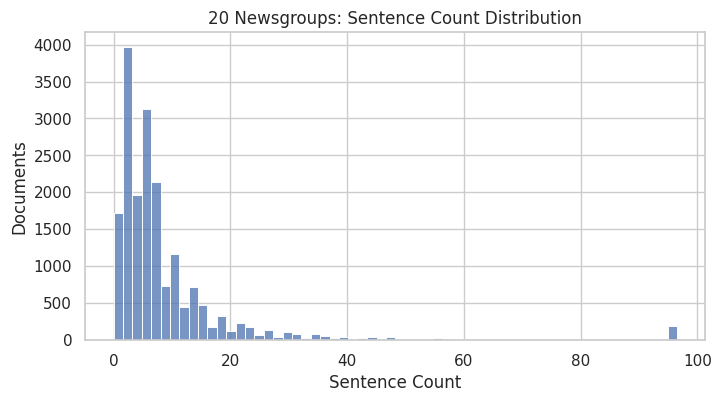

,sentence_count
count,18846.000000
mean,11.076250
std,31.557187
min,0.000000
10%,2.000000
25%,3.000000
50%,6.000000
75%,10.000000
90%,19.000000
95%,31.000000


In [14]:
plot_distribution(
    eda_20ng,
    "sentence_count",
    "20 Newsgroups: Sentence Count Distribution"
)

eda_20ng["sentence_count"].describe(
    percentiles=[.1, .25, .5, .75, .9, .95, .99]
)

Document Length Distribution

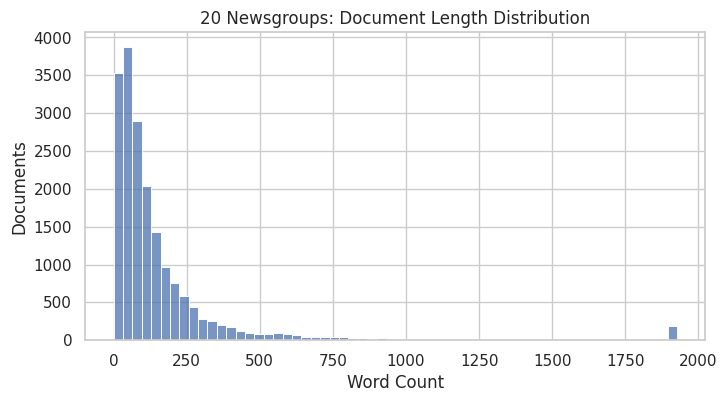

,word_count
count,18846.000000
mean,202.672928
std,738.319590
min,0.000000
10%,19.000000
25%,42.000000
50%,86.000000
75%,171.000000
90%,341.000000
95%,577.000000


In [15]:
plot_distribution(
    eda_20ng,
    "word_count",
    "20 Newsgroups: Document Length Distribution"
)

eda_20ng["word_count"].describe(
    percentiles=[.1, .25, .5, .75, .9, .95, .99]
)

Class/Topic Distribution

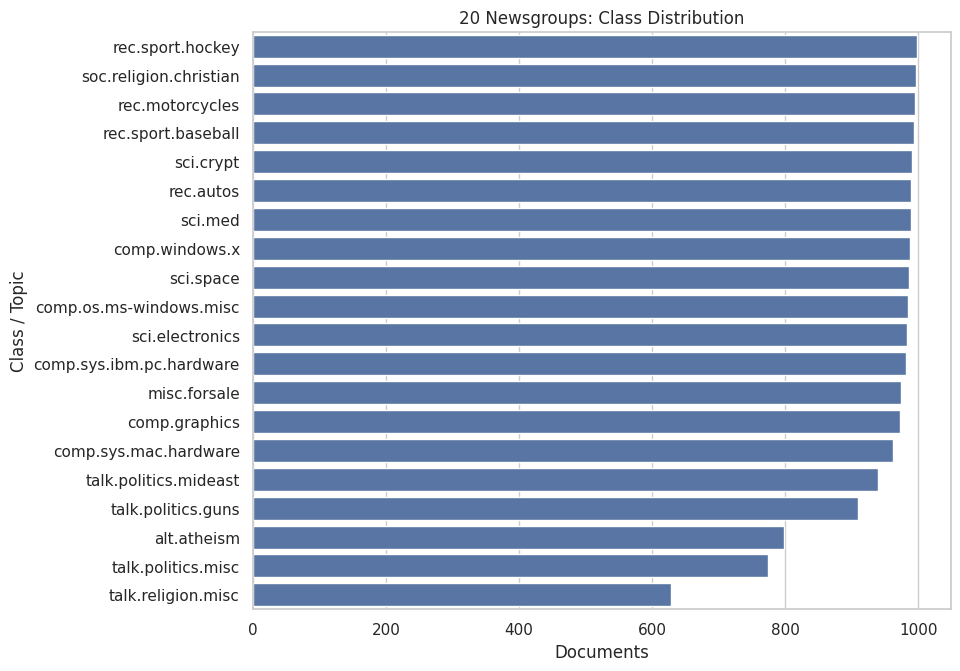

,class,document_count
0,rec.sport.hockey,999
1,soc.religion.christian,997
2,rec.motorcycles,996
3,rec.sport.baseball,994
4,sci.crypt,991
5,rec.autos,990
6,sci.med,990
7,comp.windows.x,988
8,sci.space,987
9,comp.os.ms-windows.misc,985


In [16]:
plot_label_distribution(
    eda_20ng,
    title="20 Newsgroups: Class Distribution"
)

eda_20ng["label"].value_counts().rename_axis("class").reset_index(
    name="document_count"
)

In [17]:
vocab_stats_20ng

,0
vocabulary_size,5.000000e+04
total_counted_tokens,1.815635e+06
mean_counted_terms_per_doc,9.634060e+01
median_counted_terms_per_doc,3.900000e+01


In [18]:
vocab_stats_20ng.head(30)

,0
vocabulary_size,5.000000e+04
total_counted_tokens,1.815635e+06
mean_counted_terms_per_doc,9.634060e+01
median_counted_terms_per_doc,3.900000e+01


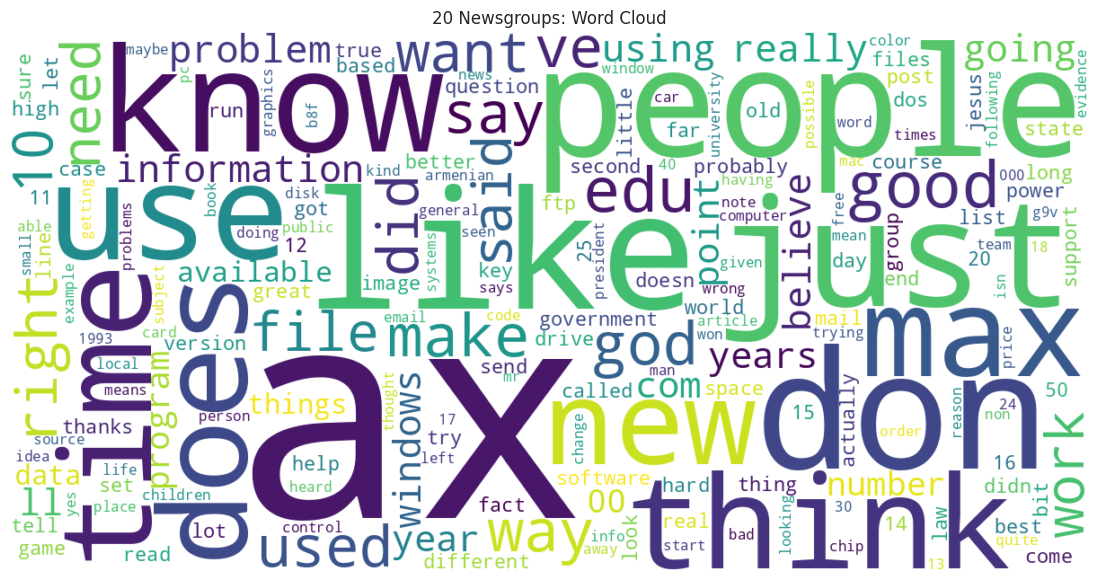

In [19]:
wc_20ng = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(
    dict(zip(vocab_20ng["term"], vocab_20ng["count"]))
)

plt.figure(figsize=(14, 7))
plt.imshow(wc_20ng, interpolation="bilinear")
plt.axis("off")
plt.title("20 Newsgroups: Word Cloud")
plt.show()

Examples of Short, Medium, and Long Documents

In [20]:
document_examples(eda_20ng)


SHORT DOCUMENTS

Class: rec.autos
Words: 0
Sentences: 0


Class: comp.graphics
Words: 0
Sentences: 0


Class: misc.forsale
Words: 0
Sentences: 0


MEDIUM DOCUMENTS

Class: alt.atheism
Words: 92
Sentences: 4
: Upon arriving at home, Joseph probably took advantage of Mary...had his way : with her so to speak. Of course, word of this couldn't get around so Mary, : being the highly-religious follower that she was decided "Hey, I'll just say : that GOD impregnated me...no one will ever know!" : : Thus, seen as a trustworthy and honorable soul, she was believed... : : And then came Jesus, the child born from violence. : : : Dave, Can you explain the purpose of your post, I can't imagine what you must have thougt it meant.

Class: misc.forsale
Words: 60
Sentences: 2
Brand new, still shrink wraped Stealth 24 for sale $150 plus shipping and COD. Specifications: Based on S3 801/805 32bit coporcessor, 1024x768x256 72Hz Ni, 800x600x64K NI, 640x480x16million NI, system requires 386 or 486 based IS

A document is flagged as too short if it has fewer than 3 sentences or fewer than 50 words.

A document is flagged as too noisy if it has low alphabetic content, many URLs, or zero words.

In [21]:
modelling_quality_summary(eda_20ng)

,0
documents,18846.00
too_short_count,2417.00
too_short_pct,12.83
too_noisy_count,533.00
too_noisy_pct,2.83
usable_sentence_level_count,16429.00
usable_sentence_level_pct,87.17
exceeds_bert_limit_pct,9.66


In [22]:
quality_by_class_20ng = (
    eda_20ng
    .groupby("label")
    .apply(modelling_quality_summary)
    .reset_index()
)

quality_by_class_20ng

/tmp/ipykernel_8524/1708116766.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(modelling_quality_summary)


,label,documents,too_short_count,too_short_pct,too_noisy_count,too_noisy_pct,usable_sentence_level_count,usable_sentence_level_pct,exceeds_bert_limit_pct
0,alt.atheism,799.0,103.0,12.89,20.0,2.50,696.0,87.11,10.76
1,comp.graphics,973.0,116.0,11.92,20.0,2.06,857.0,88.08,7.09
2,comp.os.ms-windows.misc,985.0,126.0,12.79,38.0,3.86,859.0,87.21,5.38
3,comp.sys.ibm.pc.hardware,982.0,82.0,8.35,19.0,1.93,900.0,91.65,4.48
4,comp.sys.mac.hardware,963.0,126.0,13.08,35.0,3.63,837.0,86.92,3.63
5,comp.windows.x,988.0,97.0,9.82,8.0,0.81,891.0,90.18,5.36
6,misc.forsale,975.0,166.0,17.03,16.0,1.64,809.0,82.97,4.92
7,rec.autos,990.0,159.0,16.06,54.0,5.45,831.0,83.94,4.04
8,rec.motorcycles,996.0,183.0,18.37,27.0,2.71,813.0,81.63,3.41
9,rec.sport.baseball,994.0,181.0,18.21,37.0,3.72,813.0,81.79,7.55


In [23]:
# Create a version of 20 Newsgroups for the modelling pipeline.
#
# We keep only documents that passed the EDA quality checks.
# This connects EDA directly to modelling.

df_peer_20ng = eda_20ng[
    eda_20ng["usable_sentence_level"]
][["text", "label"]].copy()

# The peer pipeline expects a split column.
# Since we are using the full cleaned dataset here, we mark all rows as "all".
df_peer_20ng["split"] = "all"

# Reorder columns to match peer's expected format:
# text | split | label
df_peer_20ng = df_peer_20ng[["text", "split", "label"]]

df_peer_20ng.head()


,text,split,label
0,\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pe...,all,rec.sport.hockey
1,My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM. Does an...,all,comp.sys.ibm.pc.hardware
2,"\n\n\n\n\tFinally you said what you dream about. Mediterranean???? That was new....\n\tThe area will be ""greater"" af...",all,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA transfers NOT the disks...\n\nThe SCSI card can do DMA transfers contai...,all,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cannot use with my new system.\n My understanding is that I have to upsate...,all,comp.sys.mac.hardware


In [24]:
print("Original 20 Newsgroups documents:", len(eda_20ng))
print("Documents exported for modelling:", len(df_peer_20ng))
print("Classes:", df_peer_20ng["label"].nunique())

Original 20 Newsgroups documents: 18846
Documents exported for modelling: 16429
Classes: 20


In [25]:
df_peer_20ng.to_csv(
    "corpus_20ng.tsv",
    sep="\t",
    index=False,
    header=False
)